In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from tensorflow.keras import layers, models
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

print("TensorFlow version:", tf.__version__)

# Load CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Flatten labels
y_train = y_train.flatten()
y_test = y_test.flatten()

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

class_names = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer",
    "Dog", "Frog", "Horse", "Ship", "Truck"
]

TensorFlow version: 2.20.0
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1689s 10us/step
Training data: (50000, 32, 32, 3)
Testing data: (10000, 32, 32, 3)


In [ ]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

In [ ]:
from google.colab import files
def save_plot(filename):

    path = f"{filename}.eps"
    plt.savefig(path, format='eps', dpi=600, bbox_inches='tight')
    files.download(path)
    print(f"Saved and downloaded: {path}")

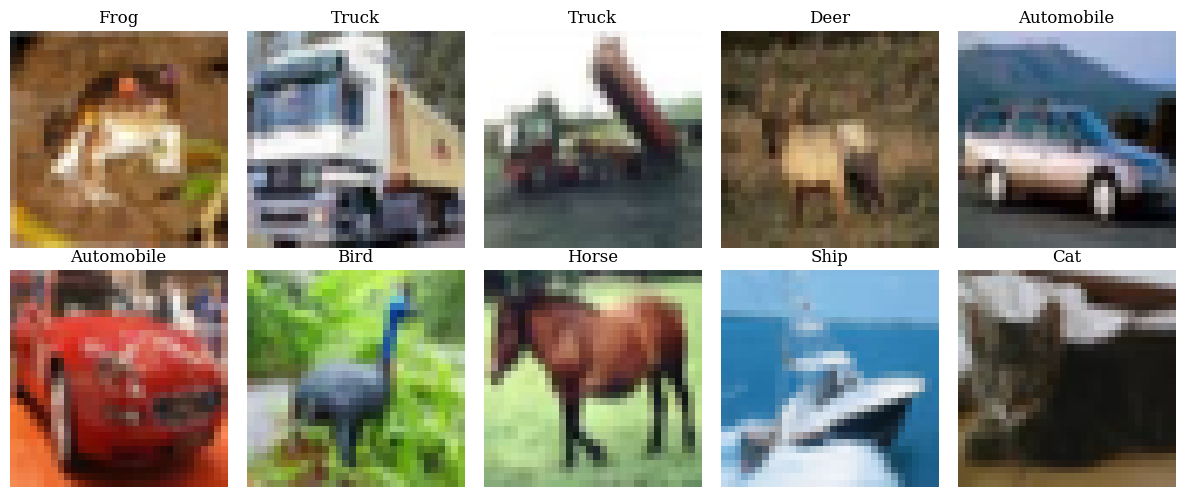

In [ ]:
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
x_train_resnet = preprocess_input(x_train.astype("float32"))
x_test_resnet = preprocess_input(x_test.astype("float32"))

print("Training shape:", x_train_resnet.shape)
print("Testing shape:", x_test_resnet.shape)

Training shape: (50000, 32, 32, 3)
Testing shape: (10000, 32, 32, 3)


In [ ]:
# Resize images for ResNet50
resize_layer = layers.Resizing(96, 96)

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

# Freeze convolutional base
base_model.trainable = False

model = models.Sequential([
    resize_layer,
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing (Resizing)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
start_time = time.time()

history = model.fit(
    x_train_resnet,
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)

training_time = time.time() - start_time

print(f"Training time: {training_time:.2f} seconds")

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 61s 33ms/step - accuracy: 0.8226 - loss: 0.5272 - val_accuracy: 0.8440 - val_loss: 0.4523
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 36s 26ms/step - accuracy: 0.8721 - loss: 0.3693 - val_accuracy: 0.8614 - val_loss: 0.4018
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.8905 - loss: 0.3085 - val_accuracy: 0.8528 - val_loss: 0.4540
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 33s 24ms/step - accuracy: 0.9071 - loss: 0.2602 - val_accuracy: 0.8654 - val_loss: 0.4359
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 36s 26ms/step - accuracy: 0.9232 - loss: 0.2161 - val_accuracy: 0.8670 - val_loss: 0.4418
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 35s 25ms/step - accuracy: 0.9341 - loss: 0.1808 - val_accuracy: 0.8586 - val_loss: 0.4903
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 34s 25ms/step - accuracy: 0.9470 - loss: 0.1468 - val_accuracy: 0.8562 - val_loss: 0.5511
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 36s 26ms/step - accuracy: 0.9539 -

In [ ]:
test_loss_before, test_acc_before = model.evaluate(
    x_test_resnet,
    y_test,
    verbose=0
)

print("Testing Accuracy before fine-tuning:",
      round(test_acc_before * 100, 2), "%")

Testing Accuracy before fine-tuning: 85.22 %


In [ ]:
# Unfreeze the ResNet50 base
base_model.trainable = True

# Freeze all layers except the last ~30 layers
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

start_finetune = time.time()

history_finetune = model.fit(
    x_train_resnet,
    y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=32,
    verbose=1
)

finetune_time = time.time() - start_finetune

print(f"Fine-tuning time: {finetune_time:.2f} seconds")

Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 84s 46ms/step - accuracy: 0.9809 - loss: 0.0569 - val_accuracy: 0.8996 - val_loss: 0.3759
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 50s 36ms/step - accuracy: 0.9887 - loss: 0.0342 - val_accuracy: 0.8950 - val_loss: 0.4194
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 49s 35ms/step - accuracy: 0.9921 - loss: 0.0257 - val_accuracy: 0.9062 - val_loss: 0.3917
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 50s 35ms/step - accuracy: 0.9931 - loss: 0.0223 - val_accuracy: 0.9046 - val_loss: 0.3888
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 49s 35ms/step - accuracy: 0.9946 - loss: 0.0181 - val_accuracy: 0.9068 - val_loss: 0.4174
Fine-tuning time: 283.76 seconds


In [ ]:
test_loss, test_accuracy = model.evaluate(
    x_test_resnet,
    y_test,
    verbose=0
)

print("Final Test Accuracy:",
      round(test_accuracy * 100, 2), "%")

Final Test Accuracy: 89.98 %


In [ ]:
y_prob = model.predict(
    x_test_resnet,
    batch_size=32,
    verbose=1
)

y_pred = np.argmax(y_prob, axis=1)

print("Predictions generated.")

313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 46ms/step
Predictions generated.


In [ ]:
precision = precision_score(
    y_test, y_pred, average="weighted"
)

recall = recall_score(
    y_test, y_pred, average="weighted"
)

f1 = f1_score(
    y_test, y_pred, average="weighted"
)

print("Accuracy :", round(test_accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1-score :", round(f1, 4))
print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)

Accuracy : 0.8998
Precision: 0.901
Recall   : 0.8998
F1-score : 0.8999
              precision    recall  f1-score   support

    Airplane       0.93      0.92      0.92      1000
  Automobile       0.94      0.93      0.94      1000
        Bird       0.84      0.92      0.88      1000
         Cat       0.84      0.79      0.81      1000
        Deer       0.88      0.88      0.88      1000
         Dog       0.81      0.87      0.84      1000
        Frog       0.95      0.91      0.93      1000
       Horse       0.95      0.90      0.92      1000
        Ship       0.94      0.94      0.94      1000
       Truck       0.92      0.94      0.93      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: conf_matrix.eps


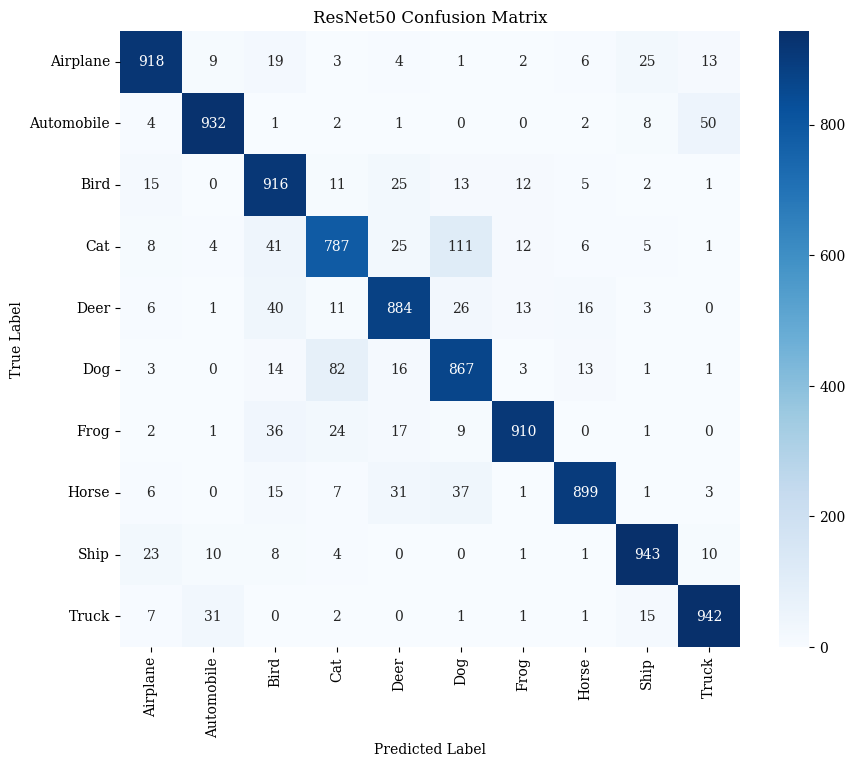

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("ResNet50 Confusion Matrix")
save_plot("conf_matrix")
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saved and downloaded: acc_plots.eps


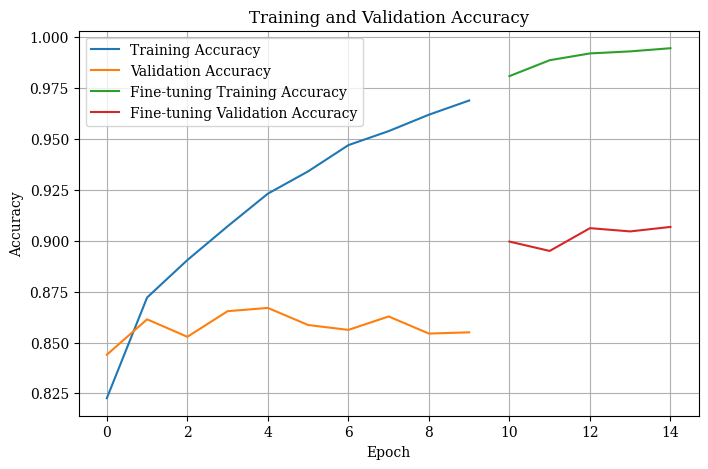

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.plot(
    range(len(history.history["accuracy"]),
          len(history.history["accuracy"]) +
          len(history_finetune.history["accuracy"])),
    history_finetune.history["accuracy"],
    label="Fine-tuning Training Accuracy"
)

plt.plot(
    range(len(history.history["val_accuracy"]),
          len(history.history["val_accuracy"]) +
          len(history_finetune.history["val_accuracy"])),
    history_finetune.history["val_accuracy"],
    label="Fine-tuning Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()
save_plot("acc_plots")
plt.show()

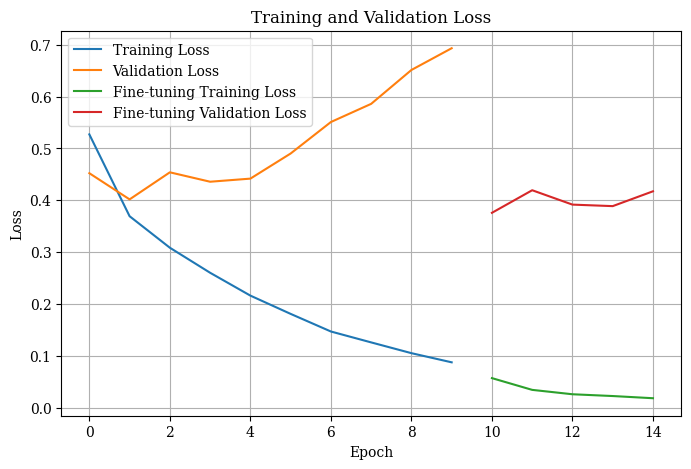

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.plot(
    range(len(history.history["loss"]),
          len(history.history["loss"]) +
          len(history_finetune.history["loss"])),
    history_finetune.history["loss"],
    label="Fine-tuning Training Loss"
)

plt.plot(
    range(len(history.history["val_loss"]),
          len(history.history["val_loss"]) +
          len(history_finetune.history["val_loss"])),
    history_finetune.history["val_loss"],
    label="Fine-tuning Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
save_plot("loss_plots")
plt.show()

In [ ]:
print("Accuracy Before Fine-tuning:",
      round(test_acc_before * 100, 2), "%")

print("Accuracy After Fine-tuning :",
      round(test_accuracy * 100, 2), "%")

improvement = (
    test_accuracy - test_acc_before
) * 100

print("Improvement:",
      round(improvement, 2), "percentage points")

Accuracy Before Fine-tuning: 85.22 %
Accuracy After Fine-tuning : 89.98 %
Improvement: 4.76 percentage points


In [ ]:
hyperparameter_results = {
    "Learning Rate": ["0.001", "0.0001"],
    "Batch Size": ["16", "32", "64"],
    "Epochs": ["10", "20"],
    "Optimizer": ["Adam", "SGD"],
    "Dense Units": ["128", "256"],
    "Frozen Layers": ["All", "Partial"]
}

for parameter, values in hyperparameter_results.items():
    print(parameter, ":", ", ".join(values))

Learning Rate : 0.001, 0.0001
Batch Size : 16, 32, 64
Epochs : 10, 20
Optimizer : Adam, SGD
Dense Units : 128, 256
Frozen Layers : All, Partial


In [ ]:
train_loss, train_accuracy = model.evaluate(
    x_train_resnet,
    y_train,
    batch_size=32,
    verbose=0
)

total_parameters = model.count_params()

print("=" * 45)
print("              RESULTS")
print("=" * 45)

print(f"Training Accuracy : {train_accuracy * 100:.2f}%")
print(f"Testing Accuracy  : {test_accuracy * 100:.2f}%")
print(f"Precision         : {precision:.4f}")
print(f"Recall            : {recall:.4f}")
print(f"F1-score          : {f1:.4f}")
print(f"Training Time     : {training_time:.2f} seconds")
print(f"Fine-tuning Time  : {finetune_time:.2f} seconds")
print(f"Total Parameters  : {total_parameters:,}")

print("=" * 45)

              RESULTS
Training Accuracy : 98.75%
Testing Accuracy  : 89.98%
Precision         : 0.9010
Recall            : 0.8998
F1-score          : 0.8999
Training Time     : 383.74 seconds
Fine-tuning Time  : 283.76 seconds
Total Parameters  : 23,851,274


In [ ]:
#Comparison of multiple CNN architectures
import tensorflow as tf
import numpy as np
import pandas as pd
import time

from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, InceptionV3
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.inception_v3 import preprocess_input as inception_preprocess

# Use a subset for architecture comparison
COMPARISON_SAMPLES = 10000

x_compare = x_train[:COMPARISON_SAMPLES]
y_compare = y_train[:COMPARISON_SAMPLES]

x_compare.shape

(10000, 32, 32, 3)

In [ ]:
#LeNet

def build_lenet():
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(6, (5, 5), activation="tanh", padding="same"),
        layers.AveragePooling2D(pool_size=(2, 2)),

        layers.Conv2D(16, (5, 5), activation="tanh"),
        layers.AveragePooling2D(pool_size=(2, 2)),

        layers.Flatten(),

        layers.Dense(120, activation="tanh"),
        layers.Dense(84, activation="tanh"),
        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
lenet = build_lenet()

start = time.time()

lenet_history = lenet.fit(
    x_compare / 255.0,
    y_compare,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)

lenet_time = time.time() - start

lenet_loss, lenet_accuracy = lenet.evaluate(
    x_test / 255.0,
    y_test,
    verbose=0
)

print("LeNet-5")
print("Parameters:", lenet.count_params())
print("Accuracy:", lenet_accuracy * 100)
print("Training time:", lenet_time)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 9s 14ms/step - accuracy: 0.3133 - loss: 1.9069 - val_accuracy: 0.3620 - val_loss: 1.8707
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3738 - loss: 1.7770 - val_accuracy: 0.3800 - val_loss: 1.7951
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4007 - loss: 1.7156 - val_accuracy: 0.4100 - val_loss: 1.7224
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4249 - loss: 1.6342 - val_accuracy: 0.4200 - val_loss: 1.6582
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4486 - loss: 1.5602 - val_accuracy: 0.4210 - val_loss: 1.6132
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.4790 - loss: 1.4793 - val_accuracy: 0.4480 - val_loss: 1.5598
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4977 - loss: 1.4048 - val_accuracy: 0.4710 - val_loss: 1.5347
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5338 - loss: 1.3340 - val_accuracy: 0

In [ ]:
#AlexNet

def build_alexnet():

    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),

        layers.Conv2D(
            96, (3, 3),
            strides=1,
            padding="same",
            activation="relu"
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(
            256, (3, 3),
            padding="same",
            activation="relu"
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(
            384, (3, 3),
            padding="same",
            activation="relu"
        ),

        layers.Conv2D(
            384, (3, 3),
            padding="same",
            activation="relu"
        ),

        layers.Conv2D(
            256, (3, 3),
            padding="same",
            activation="relu"
        ),

        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(4096, activation="relu"),
        layers.Dropout(0.5),

        layers.Dense(4096, activation="relu"),
        layers.Dropout(0.5),

        layers.Dense(10, activation="softmax")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [ ]:
alexnet = build_alexnet()

start = time.time()

alexnet_history = alexnet.fit(
    x_compare / 255.0,
    y_compare,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)

alexnet_time = time.time() - start

alexnet_loss, alexnet_accuracy = alexnet.evaluate(
    x_test / 255.0,
    y_test,
    verbose=0
)

print("AlexNet")
print("Parameters:", alexnet.count_params())
print("Accuracy:", alexnet_accuracy * 100)
print("Training time:", alexnet_time)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 24s 52ms/step - accuracy: 0.0997 - loss: 2.4262 - val_accuracy: 0.1150 - val_loss: 2.3014
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.0954 - loss: 2.3035 - val_accuracy: 0.1090 - val_loss: 2.3014
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.0976 - loss: 2.3030 - val_accuracy: 0.1080 - val_loss: 2.3014
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.1008 - loss: 2.3028 - val_accuracy: 0.1010 - val_loss: 2.3017
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.1017 - loss: 2.3029 - val_accuracy: 0.0860 - val_loss: 2.3024
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.0986 - loss: 2.3027 - val_accuracy: 0.1150 - val_loss: 2.3020
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.0967 - loss: 2.3027 - val_accuracy: 0.1150 - val_loss: 2.3018
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.1004 - loss: 2.3026 - val_acc

In [ ]:
#VGG16
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

vgg_base.trainable = False

vgg16 = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Resizing(96, 96),

    vgg_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dense(10, activation="softmax")
])

vgg16.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

vgg16.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_1 (Resizing)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 3, 3, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
start = time.time()

vgg_history = vgg16.fit(
    x_compare,
    y_compare,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)

vgg_time = time.time() - start

vgg_loss, vgg_accuracy = vgg16.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("VGG16")
print("Parameters:", vgg16.count_params())
print("Accuracy:", vgg_accuracy * 100)
print("Training time:", vgg_time)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 23s 63ms/step - accuracy: 0.5546 - loss: 1.8809 - val_accuracy: 0.6380 - val_loss: 1.1525
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - accuracy: 0.7148 - loss: 0.8427 - val_accuracy: 0.6790 - val_loss: 1.0343
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - accuracy: 0.7902 - loss: 0.6067 - val_accuracy: 0.6870 - val_loss: 0.9946
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - accuracy: 0.8407 - loss: 0.4566 - val_accuracy: 0.7040 - val_loss: 0.9870
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - accuracy: 0.8880 - loss: 0.3441 - val_accuracy: 0.7050 - val_loss: 1.0196
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - accuracy: 0.9131 - loss: 0.2688 - val_accuracy: 0.7040 - val_loss: 1.0968
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step - accuracy: 0.9414 - loss: 0.1975 - val_accuracy: 0.7030 - val_loss: 1.1713
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 14s 50ms/step - accuracy: 0.9580 - loss: 0.1482 - 

In [ ]:
#InceptionNet
inception_base = InceptionV3(
    weights="imagenet",
    include_top=False,
    input_shape=(96, 96, 3)
)

inception_base.trainable = False

googlenet = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    layers.Resizing(96, 96),

    inception_base,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),

    layers.Dense(10, activation="softmax")
])

googlenet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

googlenet.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resizing_2 (Resizing)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ inception_v3 (Functional)       │ (None, 1, 1, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,066,346 (84.18 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [ ]:
start = time.time()

googlenet_history = googlenet.fit(
    x_compare,
    y_compare,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    verbose=1
)

googlenet_time = time.time() - start

googlenet_loss, googlenet_accuracy = googlenet.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("GoogleNet / InceptionV3")
print("Parameters:", googlenet.count_params())
print("Accuracy:", googlenet_accuracy * 100)
print("Training time:", googlenet_time)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 39s 80ms/step - accuracy: 0.1746 - loss: 10.7398 - val_accuracy: 0.1120 - val_loss: 2.3128
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.1074 - loss: 2.2987 - val_accuracy: 0.1130 - val_loss: 2.3129
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.1030 - loss: 2.3002 - val_accuracy: 0.1010 - val_loss: 2.3201
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.1053 - loss: 2.2994 - val_accuracy: 0.1020 - val_loss: 2.3151
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.1033 - loss: 2.2998 - val_accuracy: 0.1070 - val_loss: 2.3216
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.1019 - loss: 2.2987 - val_accuracy: 0.1010 - val_loss: 2.3006
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.1034 - loss: 2.2999 - val_accuracy: 0.1100 - val_loss: 2.3039
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.1037 - loss: 2.2998 - val_ac

In [ ]:
architecture_results = pd.DataFrame({
    "Model": [
        "LeNet-5",
        "AlexNet",
        "VGG16",
        "GoogleNet",
        "ResNet50"
    ],

    "Parameters": [
        lenet.count_params(),
        alexnet.count_params(),
        vgg16.count_params(),
        googlenet.count_params(),
        model.count_params()
    ],

    "Accuracy (%)": [
        lenet_accuracy * 100,
        alexnet_accuracy * 100,
        vgg_accuracy * 100,
        googlenet_accuracy * 100,
        test_accuracy * 100
    ],

    "Training Time (s)": [
        lenet_time,
        alexnet_time,
        vgg_time,
        googlenet_time,
        training_time + finetune_time
    ]
})

comparison = architecture_results.copy()

comparison["Accuracy (%)"] = comparison["Accuracy (%)"].round(2)
comparison["Training Time (s)"] = comparison["Training Time (s)"].round(2)

comparison

,Model,Parameters,Accuracy (%),Training Time (s)
0,LeNet-5,83126,45.88,20.63
1,AlexNet,36926730,10.00,80.09
2,VGG16,14781642,69.26,150.09
3,GoogleNet,22066346,10.00,82.39
4,ResNet50,23851274,89.98,667.51
